In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
data=pd.read_csv('creditcard.csv')
print(data.info())


print("Class distribution:")
print(data['Class'].value_counts())
print("\nPercentage:")
print(data['Class'].value_counts(normalize=True) * 100)


print("\nAmount statistics by class:")
print(data.groupby('Class')['Amount'].describe())


print("\nFirst 5 fraud transactions:")
print(data[data['Class'] == 1].head())



<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

C:\Users\jasha\AppData\Local\Temp\ipykernel_24728\345375660.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot(box_data,labels=['Normal','Fraud'],patch_artist=True,boxprops=dict(facecolor='lightblue',alpha=0.7))


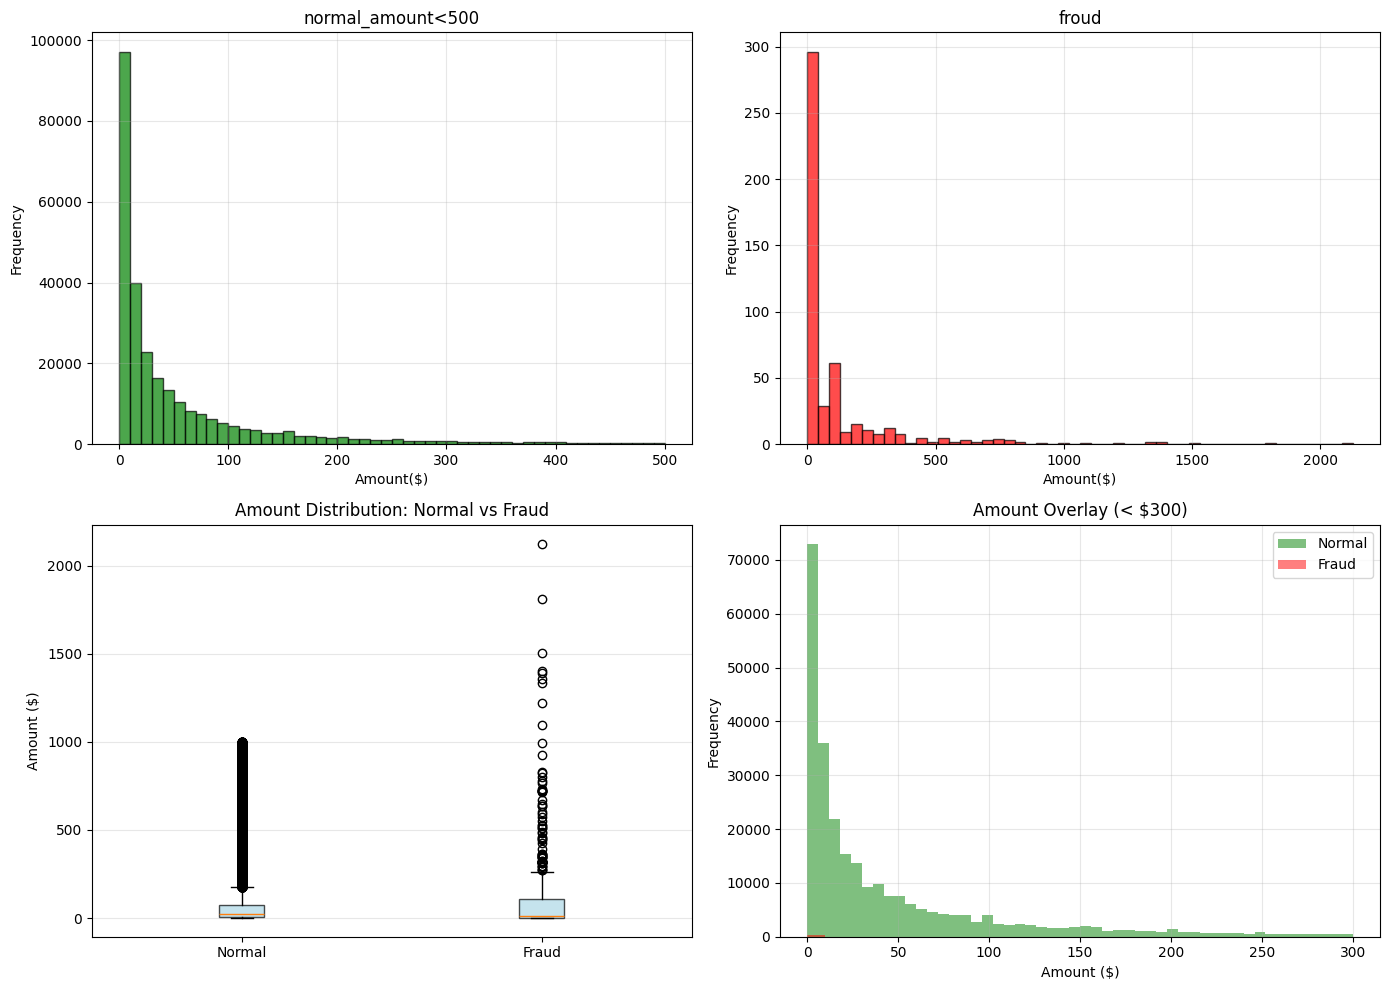

In [7]:
normal_amounts=data[data['Class']==0]['Amount']
fraud_amounts=data[data['Class']==1]['Amount']

fig,axes=plt.subplots(2,2,figsize=(14,10))

axes[0,0].hist(normal_amounts[normal_amounts<500],bins=50,color='green',alpha=0.7,edgecolor='black')
axes[0,0].set_xlabel('Amount($)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('normal_amount<500')
axes[0,0].grid(True,alpha=0.3)

axes[0,1].hist(fraud_amounts,bins=50,color='red',alpha=0.7,edgecolor='black')
axes[0,1].set_xlabel('Amount($)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('froud')
axes[0,1].grid(True,alpha=0.3)

box_data=[normal_amounts[normal_amounts<1000],fraud_amounts]
axes[1,0].boxplot(box_data,labels=['Normal','Fraud'],patch_artist=True,boxprops=dict(facecolor='lightblue',alpha=0.7))
axes[1, 0].set_ylabel('Amount ($)')
axes[1, 0].set_title('Amount Distribution: Normal vs Fraud')
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].hist(normal_amounts[normal_amounts<300], bins=50,
                alpha=0.5, color='green', label='Normal')
axes[1, 1].hist(fraud_amounts[fraud_amounts<300], bins=30,
                alpha=0.5, color='red', label='Fraud')
axes[1, 1].set_xlabel('Amount ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Amount Overlay (< $300)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


 Normal transaction-Most common hour:21:00

 Fraud transaction-most common time:19:00


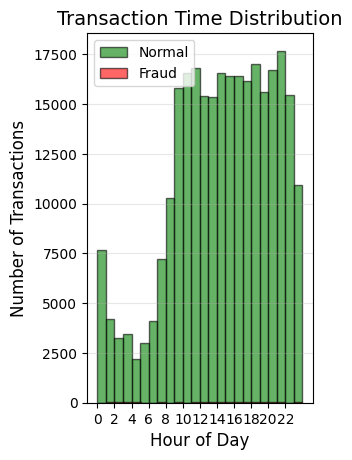

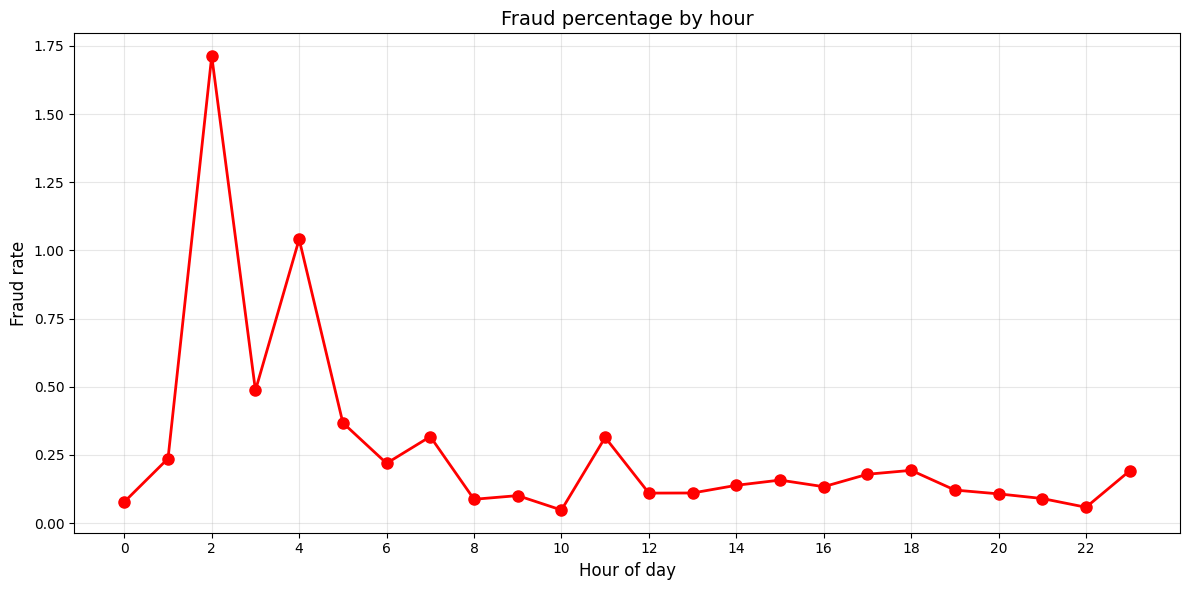

In [8]:
data['Hour']=(data['Time']/3600)%24

normal_hours=data[data['Class']==0]['Hour']
fraud_hours=data[data['Class']==1]['Hour']

print(f"\n Normal transaction-Most common hour:{normal_hours.mode()[0]:.0f}:00")
print(f"\n Fraud transaction-most common time:{fraud_hours.mode()[0]:.0f}:00")

plt.subplot(1,2,1)
plt.hist(normal_hours,bins=24,alpha=0.6,label='Normal',color='green',edgecolor='black')
plt.hist(fraud_hours,bins=24,alpha=0.6,label='Fraud',color='red',edgecolor='black')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.title('Transaction Time Distribution', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(range(0, 24, 2))

fraud_rate_by_hour=[]

for hour in range(24):
    hour_data=data[data['Hour'].astype(int)==hour]
    total=len(hour_data)
    frauds=hour_data['Class'].sum()

    if total>0:
       fraud_pct=(frauds/total)*100
    else:
        fraud_pct=0
    
    fraud_rate_by_hour.append(fraud_pct)

plt.figure(figsize=(12,6))
plt.plot(range(24),fraud_rate_by_hour,marker='o',linewidth=2,markersize=8,color='red')
plt.xlabel('Hour of day',fontsize=12)
plt.ylabel('Fraud rate',fontsize=12)
plt.title('Fraud percentage by hour',fontsize=14)
plt.xticks(range(0,24,2))
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()



In [19]:
x=data[["Time","V1","V2","V3","V4","V5","V6","V7","V8","V9","V10","V11","V12","V13","V14","V15","V16","V17","V18","V19","V20","V21","V22","V23","V24","V25","V26","V27","V28","Amount"]]
y=data["Class"]
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier( n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    class_weight='balanced_subsample',
    random_state=42)
model.fit(X_train,y_train)
prediction=model.predict(X_test)
print(prediction)
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, prediction)
print("\nConfusion Matrix:")
print(cm)

print("\nMetrics:")
print(classification_report(y_test, prediction))

[0 0 0 ... 0 0 0]

Confusion Matrix:
[[56846    18]
 [   17    81]]

Metrics:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.83      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

